## Data Visualization v2

This section visualizes a batch of preprocessed images from the training dataset to verify that the aggressive data augmentationapplied correctly. Augmentation:
* Random horizontal and vertical flips
* Random rotations, up to 20 degrees

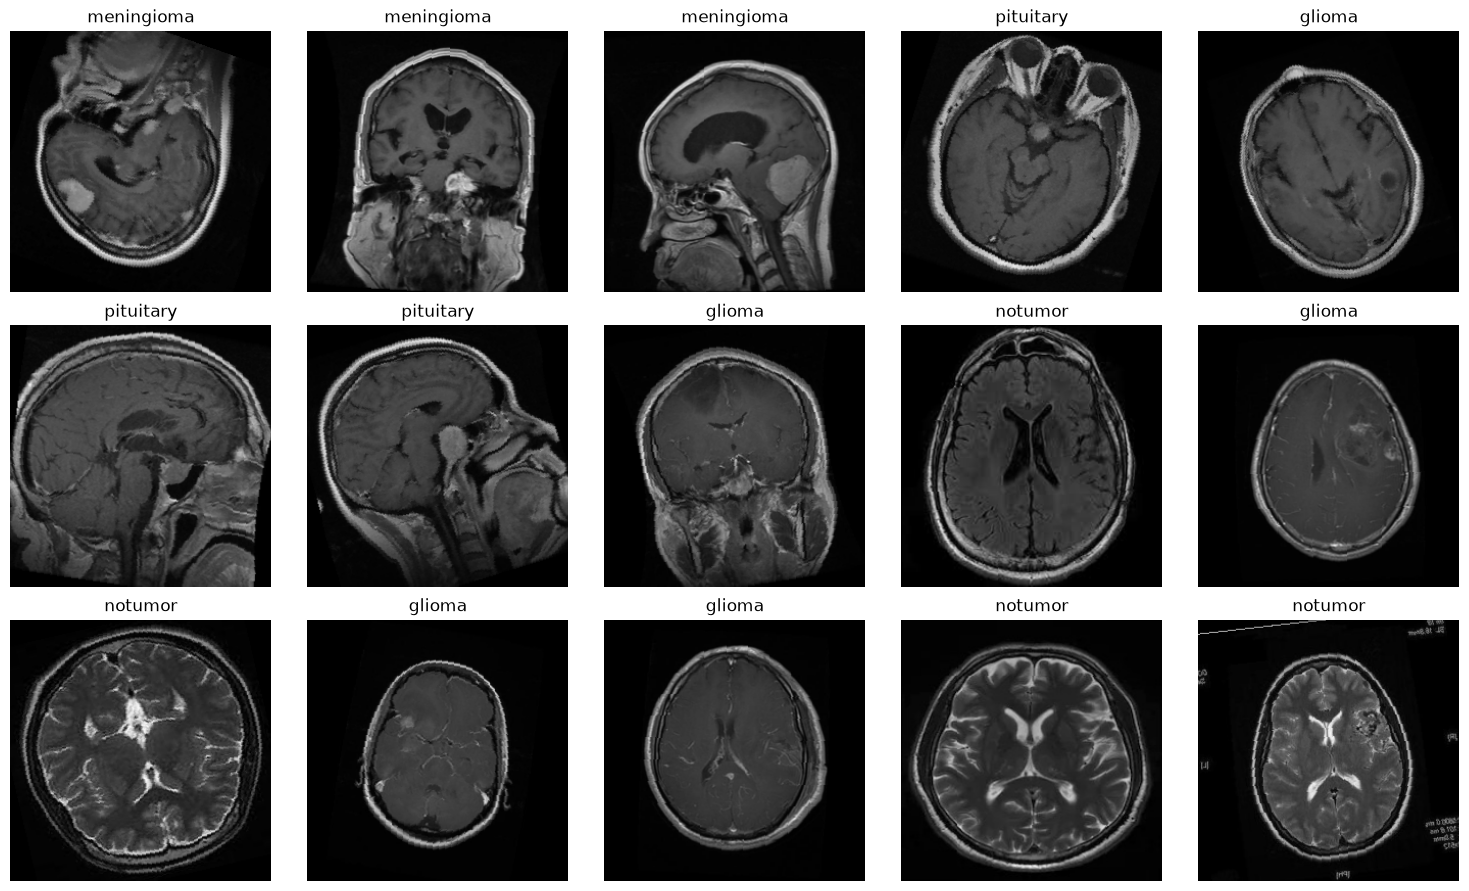

In [5]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

train_path = 'brain_mri_dataset/Training/' 
test_path = 'brain_mri_dataset/Testing/'

# training data aggressive augmentation
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),  
    transforms.RandomHorizontalFlip(), 
    transforms.RandomRotation(degrees=20),  
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(root=train_path, transform=train_transform)

# load training data in batches
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

# pulls first batch of images
images, labels = next(iter(train_loader))

# class names corresponding to the folder names
class_names = train_dataset.classes

# plot the first batch of images
fig, axes = plt.subplots(3, 5, figsize=(15,9))
axes = axes.flatten()

for i in range(15):
    img = images[i].permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].set_title(class_names[labels[i]])
    axes[i].axis('off')

plt.tight_layout()
plt.show()